    # 3. The headline on too few orders

    **Week 1, Friday. The lab debrief, chapter 3 of 3: which finding leads the note, and how sure is it?**

    Meera Raghavan reads the first line of a note and acts on it. With the data reconciled, the question
    is no longer whether the numbers are right; it is which of the right numbers deserves the first line.

    **The metric at stake.** The Q1 to Q2 fall of Rs 17,22,520, split along the revenue tree by segment:
    customers, orders per customer and revenue per order. **Who asks.** Meera, who needs to know which
    branch to open, and Marketing, who will attack any rate that rests on a handful of orders. **What a
    wrong number costs.** A trend claimed from a few orders sends a team to fix a segment that did
    nothing, while the branch that did move goes unopened for a quarter; and the first time Marketing
    asks "on how many orders?", the whole note loses the room.

    **Who else faces this.** IMDb will not rank a film in its Top 250 until it has at least 25,000 ratings from
    regular voters, and its weighted rating pulls a title with few votes toward the average of all
    titles (IMDb Help, ratings FAQ, updated 9 February 2026): a 9.4 on a few hundred votes is not
    allowed to beat a 9.0 on a million. A public case shows the cost of ignoring it: Howard Wainer's
    "The Most Dangerous Equation" shows small schools over-represented among both the best and the
    worst performers, because small samples vary more, after the Gates Foundation had put about $1.7
    billion into education grants by 2001, with small schools central to them (Wainer, Picturing the
    Uncertain World, Princeton University Press, 2009, chapter 1).

    **Where this starts.** Chapters 1 and 2 put both quarters on the books to the rupee and restored the
    one order a filter dropped. This chapter reads the clean tree, sizes four ways to choose the lead,
    and closes on the week's shuffle test run on the right unit.

**Before you read on.** This notebook runs on this morning's lab export and shows the morning's
numbers. It opens after the lab clock stops, and it is the debrief's text for self-study too.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
import time

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
QUARTERS = ("Q1", "Q2")


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q):
    return int(control[q]["amount_rs"]), int(control[q]["orders"])


print(f"{len(rows)} rows read from the lab export; Finance's control totals for {', '.join(sorted(control))}")


amt = lambda r: int(r["amount"].replace(",", ""))
kept = {}
for r in rows:
    kept.setdefault(r["order_id"], dict(r))
clean = list(kept.values())
seg_of = {}
for r in clean:
    if r["segment"]:
        seg_of.setdefault(r["customer_id"], set()).add(r["segment"])
for r in clean:
    r["amount"] = amt(r)
    if not r["segment"] and len(seg_of.get(r["customer_id"], ())) == 1:
        r["segment"] = next(iter(seg_of[r["customer_id"]]))
kit.check("the clean data lands on both control totals, from chapters 1 and 2",
          all(sum(r["amount"] for r in clean if r["quarter"] == q) == ctl(q)[0] for q in QUARTERS))

207 rows read from the lab export; Finance's control totals for Q1, Q2


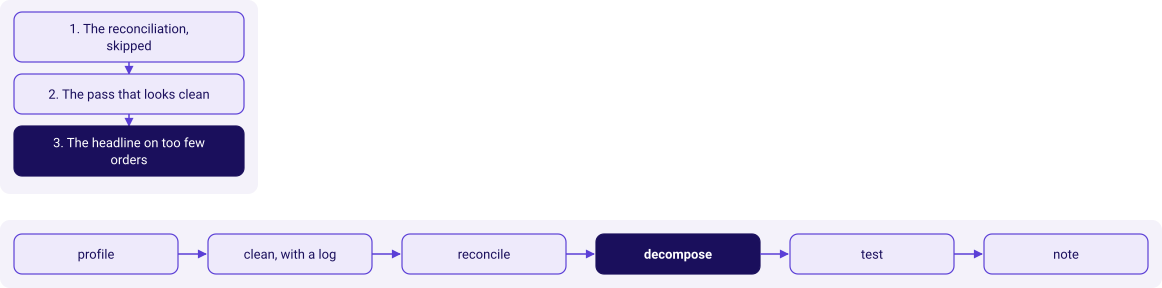

In [2]:
kit.side_by_side(
    kit.ladder(["The reconciliation, skipped", "The pass that looks clean", "The headline on too few orders"],
               lit=2, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=3, show=False),
)

## 1. The tree, segment by segment

**Predict before you run.** Which segment carries most of the Rs 17,22,520 fall?

- a) Retail-Core, the segment with the most orders.
- b) Retail-Plus, the members' tier.
- c) Business, the corporate book.
- d) Student, the smallest segment.

segment,orders Q1 / Q2,customers,orders per customer,revenue per order,revenue change,rupees moved
Retail-Core,44 / 44,30 / 30,1.47 / 1.47,"Rs 2,050 / Rs 1,700",-17.1%,"-Rs 15,400"
Retail-Plus,34 / 35,20 / 20,1.70 / 1.75,"Rs 2,800 / Rs 2,760",+1.5%,"Rs 1,400"
Student,14 / 16,12 / 12,1.17 / 1.33,Rs 900 / Rs 880,+11.7%,"Rs 1,480"
Business,6 / 4,5 / 4,1.20 / 1.00,"Rs 9,75,000 / Rs 10,35,000",-29.2%,"-Rs 17,10,000"


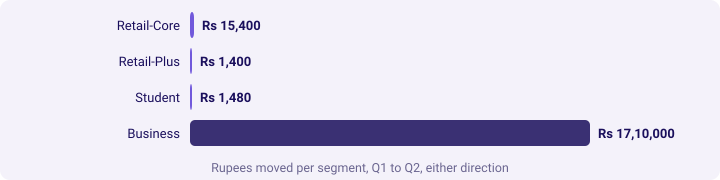

In [3]:
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")


def tree(q, seg):
    rs = [r for r in clean if r["quarter"] == q and r["segment"] == seg]
    cust = len({r["customer_id"] for r in rs})
    rev = sum(r["amount"] for r in rs)
    return {"orders": len(rs), "customers": cust, "freq": len(rs) / cust, "basket": rev / len(rs), "rev": rev}


T = {(q, s): tree(q, s) for q in QUARTERS for s in SEGS}
kit.table(["segment", "orders Q1 / Q2", "customers", "orders per customer", "revenue per order", "revenue change",
           "rupees moved"],
          [(s, f"{T['Q1', s]['orders']} / {T['Q2', s]['orders']}",
            f"{T['Q1', s]['customers']} / {T['Q2', s]['customers']}",
            f"{T['Q1', s]['freq']:.2f} / {T['Q2', s]['freq']:.2f}",
            f"{kit.rupees(T['Q1', s]['basket'])} / {kit.rupees(T['Q2', s]['basket'])}",
            f"{change(T['Q1', s]['rev'], T['Q2', s]['rev']):+.1f}%",
            kit.rupees(T['Q2', s]['rev'] - T['Q1', s]['rev'])) for s in SEGS],
          caption="The clean tree, Q1 against Q2")
fall = ctl("Q1")[0] - ctl("Q2")[0]
biz = T["Q1", "Business"]["rev"] - T["Q2", "Business"]["rev"]
kit.bars([(s, abs(T['Q2', s]['rev'] - T['Q1', s]['rev'])) for s in SEGS], lit=(3,), fmt=lambda v: kit.rupees(v),
         title="Rupees moved per segment, Q1 to Q2, either direction")
kit.check("the segments add back to the quarter", all(sum(T[q, s]["rev"] for s in SEGS) == ctl(q)[0] for q in QUARTERS))

**What happened.** The answer is c. Business carries Rs 17,10,000 of the Rs 17,22,520 fall, which is
99.3 percent of it. Business revenue fell 29.2 percent.

## 2. The trap: the headline on too few orders

**The plausible wrong answer.** "The corporate book fell 29.2 percent from Q1 to Q2 and drove the
whole decline; we recommend a corporate retention plan." It is true to the rupee, it is the biggest
number on the page, and it is the headline many notes led with.

**Predict before you run.** How many orders does that 29.2 percent rest on?

- a) About 200, the whole file.
- b) About 90, the corporate share of orders.
- c) Ten: six in Q1 and four in Q2.
- d) It cannot be counted from the export.

In [4]:
b1, b2 = T["Q1", "Business"], T["Q2", "Business"]
kit.stats([(f"{change(b1['rev'], b2['rev']):+.1f}%", "Business revenue", "the rate the note led with"),
           (f"{b1['orders']} then {b2['orders']}", "orders", "what the rate rests on"),
           (kit.rupees(biz), "the fall it carries", f"{100 * biz / fall:.1f}% of the quarter's fall")])
kit.check("the corporate rate rests on fewer than thirty orders", b1["orders"] + b2["orders"] < 30,
          f"{b1['orders'] + b2['orders']} orders")

**What happened.** The answer is c. The rate rests on ten orders. A corporate order here is worth
several lakh, so two fewer of them move the book by 29 percent.

**Why it is wrong.** The rupees are real and Meera should hear them. What the ten orders cannot carry
is the word "trend", or a plan built on it. The check is to count before you rate: put the order count
beside every rate before deciding which one leads, and ask how often chance alone moves six orders to
four. If each of the ten corporate orders were equally likely to land in either quarter, the cell
below counts how often the split comes out at least as uneven as six and four.

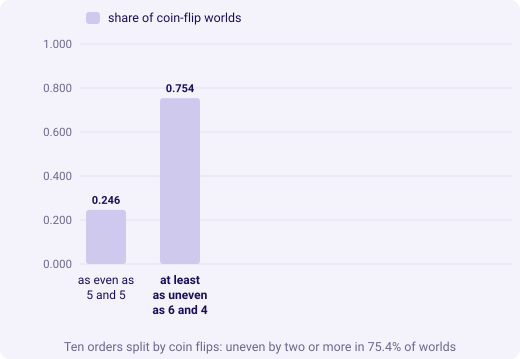

In [5]:
from math import comb
n = b1["orders"] + b2["orders"]
even = comb(n, n // 2) / 2 ** n
p_split = 1 - even if abs(b1["orders"] - b2["orders"]) >= 2 else 1.0
kit.columns(["as even as 5 and 5", "at least as uneven as 6 and 4"], [("share of coin-flip worlds", [even, p_split])],
            fmt=lambda v: f"{v:.3f}", lit=(1,), width=520,
            title=f"Ten orders split by coin flips: uneven by two or more in {p_split:.1%} of worlds")
kit.check("chance alone gives a split this uneven in most worlds", p_split > 0.5, f"{p_split:.3f}")

**The fix, and what it changes.** The corporate fall goes into the note as counts, never as a rate:
"Rs 17,10,000 of the fall is two fewer corporate orders, six in Q1 and four in Q2." Its action is a
question to whoever owns those accounts (which two did not reorder, and why), which costs a phone call.
The lead moves to the branch that moved on enough orders to read.

## The options

How does a team choose which finding leads? Four ways, each sized below on the clean tree: the claim
it leads with, the orders behind that claim, how often chance alone produces it, and the analyst
minutes it costs at the lab brief's pace.

| Option | How it picks the lead |
|---|---|
| A. The biggest rupee move | Whatever moved most in rupees leads |
| B. The total, unsplit | The quarter's change leads and the split is left out |
| C. Count before rate | Every rate carries its order count; a rate on fewer than about thirty orders goes to the caveat as counts, and the lead is the branch that moved on enough orders and survives one test |
| D. Test everything | A shuffle test on every segment, and the smallest p-value leads |

option,leads with,orders behind it,chance alone,analyst minutes
A. biggest rupee move,Business -29.2%,10,0.75 (coin flips),5
"B. the total, unsplit",revenue -28.5%,197,not asked,2
C. count before rate,Retail-Core basket -17.1%,88,0.0195 (shuffle),15
D. test everything,the smallest of four p-values,10 to 88,0.19 false alarm,45


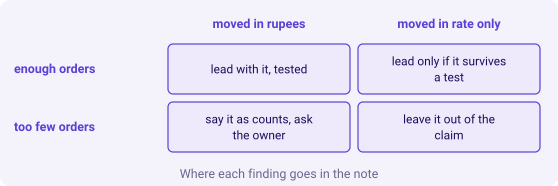

In [6]:
def basket_change(rs):
    a = [r["amount"] for r in rs if r["quarter"] == "Q1"]
    b = [r["amount"] for r in rs if r["quarter"] == "Q2"]
    return change(sum(a) / len(a), sum(b) / len(b))


core = [r for r in clean if r["segment"] == "Retail-Core"]
plus = [r for r in clean if r["segment"] == "Retail-Plus"]
observed = basket_change(core) - basket_change(plus)
groups = {}
for r in core + plus:
    groups.setdefault(r["customer_id"], []).append(r)
members = sorted(groups)
n_core = len({r["customer_id"] for r in core})


def shuffled_gap(rng):
    m = members[:]
    rng.shuffle(m)
    return basket_change([r for c in m[:n_core] for r in groups[c]]) - basket_change([r for c in m[n_core:] for r in groups[c]])


rng = random.Random(7)
gaps = [shuffled_gap(rng) for _ in range(2000)]
p_core = sum(1 for g in gaps if abs(g) >= abs(observed)) / 2000
false_alarm = 1 - 0.95 ** 4
kit.table(["option", "leads with", "orders behind it", "chance alone", "analyst minutes"], [
    ("A. biggest rupee move", f"Business {change(b1['rev'], b2['rev']):+.1f}%", n, f"{p_split:.2f} (coin flips)", 5),
    ("B. the total, unsplit", f"revenue {change(ctl('Q1')[0], ctl('Q2')[0]):+.1f}%", ctl("Q1")[1] + ctl("Q2")[1],
     "not asked", 2),
    ("C. count before rate", f"Retail-Core basket {basket_change(core):+.1f}%", len(core), f"{p_core:.4f} (shuffle)", 15),
    ("D. test everything", "the smallest of four p-values", "10 to 88", f"{false_alarm:.2f} false alarm", 45),
], caption="Four ways to choose the lead, sized on the clean tree")
kit.matrix(["enough orders", "too few orders"], ["moved in rupees", "moved in rate only"],
           [["lead with it, tested", "lead only if it survives a test"],
            ["say it as counts, ask the owner", "leave it out of the claim"]],
           title="Where each finding goes in the note")

In [7]:
kit.check("Retail-Core's basket rests on more than thirty orders", len(core) > 30, f"{len(core)} orders")
kit.check("the Retail-Core gap is one chance rarely produces, at the customer level", p_core < 0.05, f"p = {p_core:.4f}")

**The best-fit call.** C. It costs about fifteen minutes and one test, and it leads with a finding
that rests on 88 orders and that came up as large in only about 2 of every 100 chance-only worlds.
A leads on ten orders. B hides the one thing Meera most needs, that 99 percent of the fall is two
orders. D spends three times the minutes to run four tests, and with four tests at 0.05 the chance
that at least one looks real by luck is about 19 percent.

**What would change the call.** A question about accounts rather than rates: if Meera asked "what
happened to our corporate revenue?", the lead is the corporate fall, said as counts, with the two
accounts named by their owner. A corporate book of hundreds of orders a quarter would let its rate
lead. And a second quarter of the same move in Business would turn a phone call into a trend worth
testing.

## 3. The branch that moved, tested on the right unit

Retail-Core keeps its 30 customers and orders about 1.47 times each in both quarters, while its
revenue per order falls. Thursday's test asks whether that fall differs from Retail-Plus's by more
than chance produces. The label is shuffled across customers, because a customer's orders belong
together.

**Predict before you run.** Where does the observed gap sit among 2,000 customer-level shuffles?

- a) In the middle of the pile.
- b) At the edge: only a few dozen shuffles are as large.
- c) Beyond every shuffle.
- d) The test cannot run with segments of different sizes.

observed gap -15.6 points; 39 of 2,000 customer shuffles as large; p = 0.0195


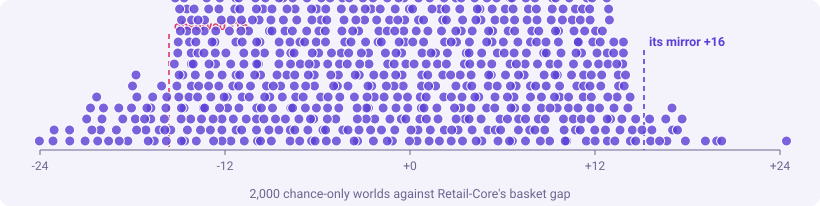

In [8]:
print(f"observed gap {observed:+.1f} points; {round(p_core * 2000)} of 2,000 customer shuffles as large; p = {p_core:.4f}")
kit.strip(gaps, markers=[("observed", observed, "bad"), ("its mirror", -observed, "plain")], lo=-24, hi=24,
          fmt=lambda v: f"{v:+.0f}", title="2,000 chance-only worlds against Retail-Core's basket gap")
kit.check("Retail-Core's customers and frequency hold while its basket falls",
          T["Q1", "Retail-Core"]["customers"] == T["Q2", "Retail-Core"]["customers"]
          and abs(T["Q1", "Retail-Core"]["freq"] - T["Q2", "Retail-Core"]["freq"]) < 0.01)

**What happened.** The answer is b. Only 39 of 2,000 shuffles produce a gap as large, p = 0.0195:
a gap this size turns up in about 2 of every 100 worlds where segment made no difference. That is a
share of chance-only worlds, never the chance the finding is wrong.

**The note, with the right lead.** Claim: booked revenue fell 28.5 percent, Rs 60,48,000 to Rs
43,25,480; Rs 17,10,000 of it is two fewer corporate orders (six, then four), and among consumers the
branch that moved is Retail-Core's revenue per order, down 17.1 percent with its 30 customers and
their frequency unchanged. Evidence: both quarters reconcile to Finance's control totals; the basket
gap came up in 39 of 2,000 customer-level shuffles. Caveat: the corporate move rests on ten orders.
Action: ask the corporate account owner which two accounts did not reorder, and open Retail-Core's
basket (items per order and price per item) before any spend.

## A second route: customer by customer

The shuffle compares averages. A second route reads each customer on their own: of Retail-Core's
customers who ordered in both quarters, how many saw their own average order fall? If the basket
fall is real and broad, most of them should.

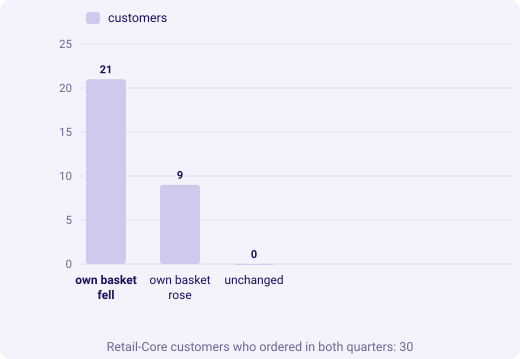

In [9]:
per = {}
for r in core:
    per.setdefault(r["customer_id"], {"Q1": [], "Q2": []})[r["quarter"]].append(r["amount"])
both = {c: v for c, v in per.items() if v["Q1"] and v["Q2"]}
fell = sum(1 for v in both.values() if sum(v["Q2"]) / len(v["Q2"]) < sum(v["Q1"]) / len(v["Q1"]))
rose = sum(1 for v in both.values() if sum(v["Q2"]) / len(v["Q2"]) > sum(v["Q1"]) / len(v["Q1"]))
kit.columns(["own basket fell", "own basket rose", "unchanged"], [("customers", [fell, rose, len(both) - fell - rose])],
            lit=(0,), width=520, title=f"Retail-Core customers who ordered in both quarters: {len(both)}")
kit.check("most customers who ordered in both quarters saw their own basket fall", fell > len(both) / 2,
          f"{fell} of {len(both)}")
kit.check("the second route points the same way as the shuffle", (fell > rose) == (basket_change(core) < 0))

**When to switch routes.** The shuffle says whether the gap is bigger than chance; the customer count
says whether it is broad or carried by a few people. When the two disagree, a handful of customers
moved the average, and the note says so.

> **Kavya's review.** Say the count before the rate, every time. "Six orders, then four" is honest.
> "Down 29 percent" alone is a headline, and Marketing will take it apart with one question.

### In the interview

**[S] Tell me about an analysis you did: what did you find, and how sure are you?** "On a two-quarter
export, revenue fell 28.5 percent after I reconciled it to Finance's control totals. Almost all of it
was two fewer corporate orders, six against four, which I reported as counts and passed to the account
owner rather than calling a trend. The finding I led with was Retail-Core's revenue per order, down
17.1 percent on 88 orders with customers and frequency flat; a customer-level shuffle put the gap at
p = 0.02, and 19 of the 30 customers saw their own basket fall. My caveat was the ten corporate
orders."

**[D] A stakeholder attacks your caveat in front of the room.** "I restate the claim with its count,
bound what the data can say, and offer the test that would settle it with its size and time. For the
corporate book: ten orders cannot tell a trend from two accounts pausing; a call to the account owner
settles which it is by Monday."

**The design question: four segments moved; which do you test?** "One: the branch the tree says moved
on enough orders to read. Testing all four at 0.05 gives about a one-in-five chance that something
looks real by luck, and a test on ten orders cannot say anything a count does not."

### Depth: the wrong unit, and the typical order

Shuffling orders instead of customers splits each customer's orders across both groups, builds worlds
that could not exist and widens the chance spread. The cell below reruns the test that way.

In [10]:
both_rows = core + plus
rng = random.Random(7)
ext = 0
for _ in range(2000):
    idx = list(range(len(both_rows)))
    rng.shuffle(idx)
    a = [both_rows[i] for i in idx[:len(core)]]
    b = [both_rows[i] for i in idx[len(core):]]
    if abs(basket_change(a) - basket_change(b)) >= abs(observed):
        ext += 1
amounts = sorted(r["amount"] for r in clean)
kit.table(["measure", "value"], [("p, shuffling customers", f"{p_core:.4f}"), ("p, shuffling orders", f"{ext / 2000:.4f}"),
                                 ("mean order, clean", kit.rupees(statistics.mean(amounts))),
                                 ("median order, clean", kit.rupees(statistics.median(amounts)))],
          caption="Two more ways a clean file still misleads")
kit.check("shuffling the wrong unit moves the verdict across 0.05", ext / 2000 > 0.05 > p_core)

measure,value
"p, shuffling customers",0.0195
"p, shuffling orders",0.0755
"mean order, clean","Rs 52,657"
"median order, clean","Rs 2,120"


The mean order is pulled up by the corporate orders, so it describes no order anybody placed; the
median is the typical one, and the mean belongs in anything that must reconcile.

In [11]:
kit.check_summary()